# Part 2 · Synthetic Data Generation for *Solea senegalensis*

**Series:** Beyond the Scale — Can Synthetic Data Solve the Small-Dataset Problem in Aquaculture AI?  
**Notebook:** `part2_synthetic_generation.ipynb`  
**Requires:** `data/processed/real_train.parquet` (created in `part1_eda_v2.ipynb`)  
**Never loads:** `data/processed/real_test.parquet` — sealed until Part 3

---

## Objectives

1. Fit three SDV synthesisers (GaussianCopula, CTGAN, TVAE) on the real training set.
2. Generate 5 independent replicas at 4 augmentation proportions (25 %, 50 %, 100 %, 200 %).
3. Apply biological validity filters and compute pass rates.
4. Evaluate univariate fidelity, multivariate fidelity and allometric preservation.
5. Compute a preliminary TSTR benchmark (Train on Synthetic, Test on Real via CV).
6. Save all synthetic datasets + manifest for Part 3.

**Methodological contract:** The test set is not loaded, inspected or referenced in this notebook.

---
## 0 · Environment verification

In [2]:
import sys
import importlib
from pathlib import Path

# ── version report ────────────────────────────────────────────────────────────
# Check that all required libraries are installed and print their versions.
# This block must be executed first so that any missing dependency is detected
# before any other import is attempted.
libs = ["sdv", "pandas", "numpy", "scipy", "sklearn", "matplotlib", "seaborn"]
for lib in libs:
    try:
        m = importlib.import_module(lib)
        print(f"  {lib:15s} {m.__version__}")
    except ImportError:
        print(f"  {lib:15s} NOT INSTALLED")

print(f"\n  Python {sys.version}")

# ── enforce SDV ≥ 1.0 ─────────────────────────────────────────────────────────
# The project uses the SDV 1.x API (SingleTableMetadata, *Synthesizer classes).
# Versions 0.x used a completely different API and are not compatible.
import sdv
sdv_major = int(sdv.__version__.split(".")[0])
assert sdv_major >= 1, (
    f"SDV ≥ 1.0 required. Installed: {sdv.__version__}. "
    "Run: pip install --upgrade sdv"
)
print("\n  SDV version check: OK")

  sdv             1.32.1
  pandas          3.0.5
  numpy           2.5.1
  scipy           1.18.0
  sklearn         1.9.0
  matplotlib      3.11.1
  seaborn         0.13.2

  Python 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 21.0.0 (clang-2100.0.123.102)]

  SDV version check: OK


---
## 1 · Imports and configuration

In [3]:
import random
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score

from sdv.metadata import SingleTableMetadata
from sdv.single_table import (
    GaussianCopulaSynthesizer,
    CTGANSynthesizer,
    TVAESynthesizer,
)

# Suppress FutureWarnings from SDV and pandas that do not affect results.
warnings.filterwarnings("ignore", category=FutureWarning)

# ── global constants ───────────────────────────────────────────────────────────
# RANDOM_STATE is the master seed used for all stochastic operations.
# Individual replicas use per-seed values from SEEDS, but this value
# initialises the global numpy and random states at startup.
RANDOM_STATE = 42

FEATURES     = ["length_cm", "width_cm", "thickness_cm"]
TARGET       = "weight_g"
FEATURES_ALL = [TARGET] + FEATURES   # order: weight first, then dims

# Augmentation proportions expressed as a fraction of N_REAL_TRAIN.
# E.g. 0.25 → generate 0.25 × 167 ≈ 42 synthetic rows per replica.
PROPORTIONS = [0.25, 0.50, 1.00, 2.00]

# Number of independent synthetic replicas per (synthesiser, proportion).
# Each replica uses a different seed from SEEDS so that variability across
# replicas can be measured separately from variability across proportions.
N_REPLICAS = 5
SEEDS      = [42, 123, 456, 789, 1024]

# ── biological validity bounds ─────────────────────────────────────────────────
# Thresholds derived from real training data and species biology.
# All rules are defined here (not inside the filter function) so they can be
# audited, adjusted and version-controlled independently of the code.
BIO_K_AREA_MIN = 0.08   # K_area = W / (L × Width)  —  Froese 2006
BIO_K_AREA_MAX = 0.50
BIO_WL_MIN     = 0.20   # width / length  —  flatfish bilateral symmetry
BIO_WL_MAX     = 0.55
BIO_TL_MIN     = 0.02   # thickness / length  —  flatfish morphology
BIO_TL_MAX     = 0.12

# ── real allometric coefficients (from Part 1 fitting) ────────────────────────
# Reference values used in Section 10 to assess exponent stability.
REAL_B = {"b1_length": 1.621, "b2_width": 0.876, "b3_thickness": 0.393}

# ── paths ──────────────────────────────────────────────────────────────────────
DATA_DIR      = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"
SYNTHETIC_DIR = DATA_DIR / "synthetic"
RESULTS_DIR   = Path("results")
METRICS_DIR   = RESULTS_DIR / "metrics"
FIGURES_DIR   = RESULTS_DIR / "figures"
CONFIGS_DIR   = Path("configs")                  # stores metadata.json and any
METADATA_PATH = CONFIGS_DIR / "metadata.json"    # other reproducibility artefacts

# Create all output directories. CONFIGS_DIR is included so that metadata.json
# can always be written without an extra mkdir call in Section 3.
for d in [SYNTHETIC_DIR, METRICS_DIR, FIGURES_DIR, CONFIGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── metadata rebuild flag ──────────────────────────────────────────────────────
# When False (default), Section 3 loads metadata.json if it already exists
# and passes all compatibility checks; it only rebuilds when necessary.
# Set to True to force a full rebuild — useful when columns, sdtypes or
# biological constraints change between runs.
FORCE_REBUILD_METADATA: bool = False

# ── global seed initialisation ─────────────────────────────────────────────────
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Configuration loaded.")
print(f"  Proportions : {PROPORTIONS}")
print(f"  Replicas    : {N_REPLICAS}")
print(f"  Seeds       : {SEEDS}")
print(f"  Total runs  : {3 * len(PROPORTIONS) * N_REPLICAS} (3 synth × 4 prop × 5 rep)")
print(f"  Configs dir : {CONFIGS_DIR.resolve()}")
print(f"  Metadata    : {METADATA_PATH}")

Configuration loaded.
  Proportions : [0.25, 0.5, 1.0, 2.0]
  Replicas    : 5
  Seeds       : [42, 123, 456, 789, 1024]
  Total runs  : 60 (3 synth × 4 prop × 5 rep)
  Configs dir : /Users/jalosuna/WorkSpaces/GitHub/synthetic-data/configs
  Metadata    : configs/metadata.json


---
## 2 · Load real training data

> **Methodological contract:** only `real_train.parquet` is loaded here.
> `real_test.parquet` is sealed until Part 3.

In [4]:
TRAIN_PATH = PROCESSED_DIR / "real_train.parquet"
TEST_PATH  = PROCESSED_DIR / "real_test.parquet"

# Hard assertion: training file must exist before any further step.
assert TRAIN_PATH.exists(), f"Training data not found: {TRAIN_PATH}"
# Sanity check: confirm the test path has not been accidentally symlinked
# or otherwise made readable from this notebook.
assert not TEST_PATH.is_symlink(), "Sanity check: TEST_PATH must not be a symlink"

df_train = pd.read_parquet(TRAIN_PATH)

print(f"Training set loaded: {df_train.shape[0]} records × {df_train.shape[1]} columns")
print(f"Columns: {df_train.columns.tolist()}")
print()
print(df_train[FEATURES_ALL].describe().round(3))

N_REAL_TRAIN = len(df_train)

# Verify no test-set rows have leaked into the training file.
print(f"\ndata_origin values in training set:")
print(df_train["data_origin"].value_counts())

Training set loaded: 167 records × 9 columns
Columns: ['weight_g', 'length_cm', 'width_cm', 'thickness_cm', 'width_length_ratio', 'thickness_length_ratio', 'K_area', 'bio_valid', 'data_origin']

       weight_g  length_cm  width_cm  thickness_cm
count   167.000    167.000   167.000       167.000
mean      5.279      7.217     2.777         0.464
std       3.434      1.459     0.688         0.113
min       0.460      3.300     1.100         0.200
25%       2.825      6.100     2.300         0.400
50%       4.290      7.000     2.700         0.500
75%       6.985      8.300     3.300         0.500
max      21.980     10.700     5.200         0.800

data_origin values in training set:
data_origin
real_train    167
Name: count, dtype: int64


---
## 3 · SDV metadata definition

The metadata object describes the schema of `df_for_synth` to SDV.
It is **persisted to `configs/metadata.json`** so that:

- Future runs can reload the exact same schema without rebuilding it.
- Results are reproducible across SDV versions that may change auto-detection behaviour.
- Any column or sdtype change is detected automatically (see `load_or_build_metadata`).

`FORCE_REBUILD_METADATA` (Section 1) overrides the cache when set to `True`.

In [5]:
def load_or_build_metadata(
    df: pd.DataFrame,
    path: Path,
    columns: list,
    sdtype: str = "numerical",
    force_rebuild: bool = False,
) -> SingleTableMetadata:
    """
    Load SDV SingleTableMetadata from a JSON file when it already exists
    and passes all compatibility checks; otherwise build it from scratch,
    validate it and save it.

    Compatibility checks performed on an existing JSON
    --------------------------------------------------
    1. The file can be parsed by SDV without errors.
    2. metadata.validate() passes (internal SDV consistency).
    3. The column set in the JSON matches the column set in `df` exactly
       (both directions: no missing columns, no extra columns).
    4. Every column listed in `columns` carries the expected `sdtype`.

    If any check fails the function logs a warning, rebuilds from scratch
    and overwrites the file.  No silent schema drift is possible.

    Parameters
    ----------
    df           : DataFrame that will be passed to the synthesiser
                   (df_for_synth — must already exclude data_origin).
    path         : File system path for the JSON (METADATA_PATH).
    columns      : Columns that must be declared with `sdtype`.
    sdtype       : Expected SDV sdtype for every column in `columns`.
                   Default 'numerical' covers all morphometric variables.
    force_rebuild: When True, skip loading regardless of file state and
                   always rebuild.  Controlled via FORCE_REBUILD_METADATA
                   in Section 1.

    Returns
    -------
    SingleTableMetadata
        A validated metadata object whose JSON representation is saved
        at `path`.  The same object is used directly by the synthesisers
        in Section 4 — no second load is needed.
    """

    def _build_and_save() -> SingleTableMetadata:
        """Build metadata from df, validate and persist to path."""
        meta = SingleTableMetadata()
        # detect_from_dataframe infers sdtypes from pandas dtypes.
        # We override every column explicitly below to avoid any
        # mis-detection (e.g. integers being labelled as 'id').
        meta.detect_from_dataframe(df)
        for col in columns:
            meta.update_column(col, sdtype=sdtype)
        meta.validate()
        path.parent.mkdir(parents=True, exist_ok=True)
        meta.save_to_json(path)
        print(f"  [metadata] Built from dataframe and saved → {path}")
        return meta

    # ── route 1: forced rebuild ────────────────────────────────────────────
    if force_rebuild:
        print("  [metadata] FORCE_REBUILD_METADATA=True — rebuilding.")
        return _build_and_save()

    # ── route 2: file does not exist ───────────────────────────────────────
    if not path.exists():
        print(f"  [metadata] {path} not found — building for the first time.")
        return _build_and_save()

    # ── route 3: file exists — run all compatibility checks ────────────────
    print(f"  [metadata] Found {path} — running compatibility checks …")

    # Check 1 · JSON parseable by SDV
    try:
        meta = SingleTableMetadata.load_from_json(path)
    except Exception as exc:
        print(f"  [metadata] WARNING: JSON could not be parsed ({exc}). Rebuilding.")
        return _build_and_save()

    # Check 2 · Internal SDV consistency
    try:
        meta.validate()
    except Exception as exc:
        print(f"  [metadata] WARNING: metadata.validate() failed ({exc}). Rebuilding.")
        return _build_and_save()

    # Check 3 · Column set matches df exactly (bidirectional)
    meta_cols = set(meta.to_dict()["columns"].keys())
    df_cols   = set(df.columns)

    missing_in_meta = df_cols  - meta_cols   # columns in df but not in JSON
    extra_in_meta   = meta_cols - df_cols    # columns in JSON but not in df

    if missing_in_meta or extra_in_meta:
        msg_parts = []
        if missing_in_meta:
            msg_parts.append(f"missing in JSON: {sorted(missing_in_meta)}")
        if extra_in_meta:
            msg_parts.append(f"extra in JSON:   {sorted(extra_in_meta)}")
        print(
            f"  [metadata] WARNING: column mismatch — "
            f"{'; '.join(msg_parts)}. Rebuilding."
        )
        return _build_and_save()

    # Check 4 · sdtype consistency for every requested column
    meta_dict  = meta.to_dict()["columns"]
    wrong_type = [
        col for col in columns
        if meta_dict.get(col, {}).get("sdtype") != sdtype
    ]
    if wrong_type:
        print(
            f"  [metadata] WARNING: unexpected sdtype for {wrong_type} "
            f"(expected '{sdtype}'). Rebuilding."
        )
        return _build_and_save()

    # All checks passed — return the loaded object directly.
    # No second disk read is needed in Section 4; this object is reused.
    print(
        f"  [metadata] All checks passed — "
        f"{len(meta_cols)} columns, sdtype='{sdtype}'. Ready."
    )
    return meta


# ── Prepare the synthesis dataframe ───────────────────────────────────────────
# df_for_synth contains only the four morphometric variables.
# data_origin and derived columns (ratios, bio_valid, etc.) are excluded:
#   · data_origin is a traceability label, not a biological measurement.
#   · Derived columns are functions of the four raw variables; including
#     them would introduce redundancy and distort the joint distribution.
df_for_synth = df_train[FEATURES_ALL].copy()

# ── Load or build metadata ────────────────────────────────────────────────────
metadata = load_or_build_metadata(
    df            = df_for_synth,
    path          = METADATA_PATH,
    columns       = FEATURES_ALL,
    sdtype        = "numerical",
    force_rebuild = FORCE_REBUILD_METADATA,
)

print()
print(metadata.to_dict())

  [metadata] Found configs/metadata.json — running compatibility checks …
  [metadata] All checks passed — 4 columns, sdtype='numerical'. Ready.

{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1', 'columns': {'weight_g': {'sdtype': 'numerical'}, 'length_cm': {'sdtype': 'numerical'}, 'width_cm': {'sdtype': 'numerical'}, 'thickness_cm': {'sdtype': 'numerical'}}}


---
## 4 · Fit synthesisers

Three models are trained on `real_train` only:

| Model | Type | Key assumption |
|---|---|---|
| GaussianCopula | Probabilistic | Gaussian dependence structure |
| CTGAN | GAN (adversarial) | Mode-specific normalisation |
| TVAE | VAE (variational) | Smooth latent space, regularised |

> `batch_size=50` (≈ n/3) is used for CTGAN and TVAE to avoid batches
> larger than the training set (standard default is 500).

In [6]:
import time

# ── Synthesiser configurations ────────────────────────────────────────────────
# All three models receive the same validated metadata object built in Section 3.
# Hyperparameters are intentionally conservative for small datasets (n=167):
#   · enforce_min_max_values=True clips synthetic samples to observed ranges.
#   · batch_size=50 avoids batches larger than the training set for GAN/VAE.
#   · epochs=500 balances convergence quality vs computational cost.
#   · cuda=False ensures CPU-only execution for reproducibility.
synthesiser_configs = {
    "gaussian_copula": GaussianCopulaSynthesizer(
        metadata,
        enforce_min_max_values=True,   # clips to [min, max] of training data
        enforce_rounding=False,         # keep full float precision
        default_distribution="norm",    # Gaussian marginals as starting point
    ),
    "ctgan": CTGANSynthesizer(
        metadata,
        epochs=500,
        batch_size=50,                  # ≈ n/3; avoids oversized batches
        generator_dim=(128, 128),
        discriminator_dim=(128, 128),
        verbose=False,
        cuda=False,
    ),
    "tvae": TVAESynthesizer(
        metadata,
        epochs=500,
        batch_size=50,                  # same rationale as CTGAN
        compress_dims=(128, 128),
        decompress_dims=(128, 128),
    ),
}

fitted    = {}   # stores trained synthesiser objects keyed by name
fit_times = {}   # wall-clock training time per synthesiser

for name, synth in synthesiser_configs.items():
    t0 = time.time()
    print(f"Fitting {name} ... ", end="", flush=True)
    synth.fit(df_for_synth)
    elapsed = time.time() - t0
    fitted[name]    = synth
    fit_times[name] = elapsed
    print(f"done ({elapsed:.1f} s)")

print("\nAll synthesisers fitted.")
print()
for name, t in fit_times.items():
    print(f"  {name:20s}  {t:.1f} s")

Fitting gaussian_copula ... done (0.0 s)
Fitting ctgan ... done (6.5 s)
Fitting tvae ... done (8.2 s)

All synthesisers fitted.

  gaussian_copula       0.0 s
  ctgan                 6.5 s
  tvae                  8.2 s


---
## 5 · Biological validity function

In [7]:
def biological_validity_check(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply morphometric validity constraints for Solea senegalensis.
    Returns a copy of df with a boolean column 'bio_valid'.

    Constraints (defined from real training data and species biology):
      1. All measurements strictly positive.
      2. K_area = weight_g / (length_cm × width_cm) ∈ [BIO_K_AREA_MIN, BIO_K_AREA_MAX]
         (Froese 2006 — condition factor adapted for area-based index).
      3. width_cm / length_cm  ∈ [BIO_WL_MIN, BIO_WL_MAX]
         (bilateral flatfish symmetry constraint).
      4. thickness_cm / length_cm ∈ [BIO_TL_MIN, BIO_TL_MAX]
         (flatfish morphology — dorso-ventral compression).

    All threshold constants are defined in Section 1 (BIO_* variables)
    so they can be adjusted without touching this function.

    Samples that fail one or more constraints are flagged as bio_valid=False
    but are NOT silently dropped here — filtering decisions are made by the
    caller, which allows separate analysis of pass rates and failure modes.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: weight_g, length_cm, width_cm, thickness_cm.

    Returns
    -------
    pd.DataFrame
        Copy of the input with an additional boolean column 'bio_valid'.
    """
    df = df.copy()

    # Rule 1 — strict positivity of all raw measurements
    positive = (
        (df["weight_g"]     > 0) &
        (df["length_cm"]    > 0) &
        (df["width_cm"]     > 0) &
        (df["thickness_cm"] > 0)
    )

    # Derived morphometric indices (computed from synthetic values, not stored)
    k_area   = df["weight_g"]     / (df["length_cm"] * df["width_cm"])
    wl_ratio = df["width_cm"]     / df["length_cm"]
    tl_ratio = df["thickness_cm"] / df["length_cm"]

    df["bio_valid"] = (
        positive &
        k_area.between(BIO_K_AREA_MIN, BIO_K_AREA_MAX) &
        wl_ratio.between(BIO_WL_MIN, BIO_WL_MAX) &
        tl_ratio.between(BIO_TL_MIN, BIO_TL_MAX)
    )
    return df


# ── Verify on real training data (reference pass rate) ────────────────────────
# The real training data should pass almost all rules (any failures indicate
# edge cases in the real dataset that may warrant review in Part 1).
df_train_checked = biological_validity_check(df_train)
n_valid_real     = df_train_checked["bio_valid"].sum()

print(f"Real training data pass rate: {n_valid_real}/{N_REAL_TRAIN} "
      f"({100*n_valid_real/N_REAL_TRAIN:.1f}%)")
print()
print("Invalid records in real training data (if any):")
invalid_real = df_train_checked[~df_train_checked["bio_valid"]]
if invalid_real.empty:
    print("  None — all real training records pass biological validity.")
else:
    print(invalid_real[["weight_g", "length_cm", "width_cm", "thickness_cm"]])

Real training data pass rate: 167/167 (100.0%)

Invalid records in real training data (if any):
  None — all real training records pass biological validity.


---
## 6 · Generate synthetic replicas

For each synthesiser: 4 proportions × 5 replicas = 20 sampling runs.  
Biological validity is applied immediately after sampling.

In [8]:
# synthetic_registry accumulates one dict per (synthesiser, proportion, replica).
# Each dict carries both metadata and the full DataFrame for downstream analysis.
# The 'df' key is excluded from the manifest JSON (Section 7) to keep it lean.
synthetic_registry = []

for synth_name, synth in fitted.items():
    print(f"\n── {synth_name} ──")
    for prop in PROPORTIONS:
        n_synth = int(N_REAL_TRAIN * prop)   # absolute row count for this prop
        for replica_idx, seed in enumerate(SEEDS):
            # Fix seed immediately before each sampling call so that results
            # are reproducible for each (synthesiser, proportion, replica)
            # independently — not dependent on execution order.
            np.random.seed(seed)
            random.seed(seed)

            df_s = synth.sample(num_rows=n_synth)
            df_s = biological_validity_check(df_s)

            # Traceability columns — appended to every synthetic row.
            # data_origin='synthetic' ensures these rows are never confused
            # with real data in downstream notebooks.
            df_s["data_origin"]      = "synthetic"
            df_s["synth_model"]      = synth_name
            df_s["synth_proportion"] = prop
            df_s["synth_replica"]    = replica_idx
            df_s["synth_seed"]       = seed

            n_valid   = int(df_s["bio_valid"].sum())
            pass_rate = n_valid / len(df_s)

            synthetic_registry.append({
                "model":       synth_name,
                "proportion":  prop,
                "replica":     replica_idx,
                "seed":        seed,
                "n_generated": len(df_s),
                "n_valid":     n_valid,
                "pass_rate":   pass_rate,
                "df":          df_s,           # full DataFrame (in-memory only)
            })

            print(f"  prop={prop:.2f} rep={replica_idx} seed={seed} → "
                  f"{n_valid}/{len(df_s)} valid ({100*pass_rate:.1f}%)")

print(f"\nTotal replicas in registry: {len(synthetic_registry)}")


── gaussian_copula ──
  prop=0.25 rep=0 seed=42 → 37/41 valid (90.2%)
  prop=0.25 rep=1 seed=123 → 38/41 valid (92.7%)
  prop=0.25 rep=2 seed=456 → 35/41 valid (85.4%)
  prop=0.25 rep=3 seed=789 → 37/41 valid (90.2%)
  prop=0.25 rep=4 seed=1024 → 35/41 valid (85.4%)
  prop=0.50 rep=0 seed=42 → 77/83 valid (92.8%)
  prop=0.50 rep=1 seed=123 → 75/83 valid (90.4%)
  prop=0.50 rep=2 seed=456 → 71/83 valid (85.5%)
  prop=0.50 rep=3 seed=789 → 79/83 valid (95.2%)
  prop=0.50 rep=4 seed=1024 → 76/83 valid (91.6%)
  prop=1.00 rep=0 seed=42 → 150/167 valid (89.8%)
  prop=1.00 rep=1 seed=123 → 149/167 valid (89.2%)
  prop=1.00 rep=2 seed=456 → 156/167 valid (93.4%)
  prop=1.00 rep=3 seed=789 → 151/167 valid (90.4%)
  prop=1.00 rep=4 seed=1024 → 158/167 valid (94.6%)
  prop=2.00 rep=0 seed=42 → 310/334 valid (92.8%)
  prop=2.00 rep=1 seed=123 → 303/334 valid (90.7%)
  prop=2.00 rep=2 seed=456 → 309/334 valid (92.5%)
  prop=2.00 rep=3 seed=789 → 310/334 valid (92.8%)
  prop=2.00 rep=4 seed=1024 →

---
## 7 · Save synthetic datasets + manifest

In [9]:
# Only bio_valid rows are saved to disk.  The pass rate for each replica is
# recorded in the manifest so Part 3 can account for filtering effects.
manifest = []

for entry in synthetic_registry:
    # Keep only valid rows; reset index for clean parquet files.
    df_valid = entry["df"][entry["df"]["bio_valid"]].copy().reset_index(drop=True)

    # File naming convention: model _ proportion(%) _ replica index
    # Example: synthetic_ctgan_p100_r02.parquet
    fname = (
        f"synthetic_{entry['model']}_"
        f"p{int(entry['proportion']*100):03d}_"
        f"r{entry['replica']:02d}.parquet"
    )
    fpath = SYNTHETIC_DIR / fname
    df_valid.to_parquet(fpath, index=False)

    manifest.append({
        "model":       entry["model"],
        "proportion":  entry["proportion"],
        "replica":     entry["replica"],
        "seed":        entry["seed"],
        "n_generated": entry["n_generated"],
        "n_valid":     entry["n_valid"],
        "pass_rate":   float(entry["pass_rate"]),
        "path":        str(fpath),
    })

# Save manifest as JSON — used by Part 3 to locate and load all synthetic files.
manifest_path = SYNTHETIC_DIR / "manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Saved {len(manifest)} synthetic datasets to {SYNTHETIC_DIR}/")
print(f"Manifest written to: {manifest_path}")

# ── Pass rate summary ──────────────────────────────────────────────────────────
df_manifest = pd.DataFrame(manifest)
print()
print("Pass rate by synthesiser (mean ± std across proportions and replicas):")
print(
    df_manifest.groupby("model")["pass_rate"]
    .agg(["mean", "std", "min", "max"])
    .round(3)
)

Saved 60 synthetic datasets to data/synthetic/
Manifest written to: data/synthetic/manifest.json

Pass rate by synthesiser (mean ± std across proportions and replicas):
                  mean    std    min    max
model                                      
ctgan            0.533  0.068  0.341  0.651
gaussian_copula  0.910  0.029  0.854  0.952
tvae             0.994  0.008  0.976  1.000


---
## 8 · Univariate fidelity

KDE overlays (real training vs synthetic) for all four variables,  
one figure per synthesiser. KS statistics reported but treated as  
supporting evidence only (n=167 gives moderate power).

  Saved: results/figures/fig_univariate_gaussian_copula.png


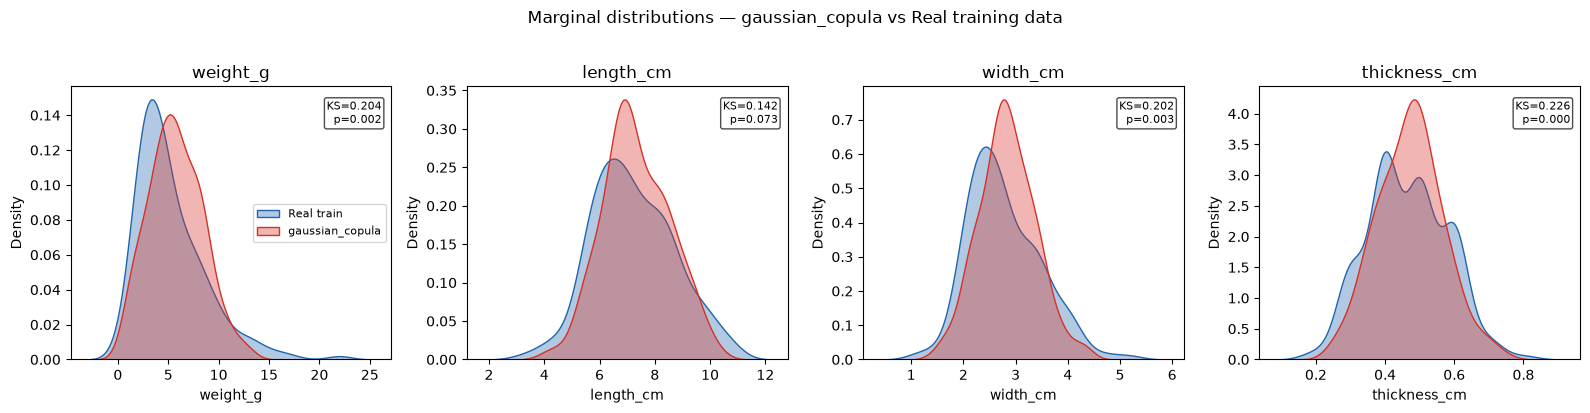


gaussian_copula — KS statistics:
  weight_g         KS=0.204  p=0.002  Δmean=+0.4227
  length_cm        KS=0.142  p=0.073  Δmean=+0.1088
  width_cm         KS=0.202  p=0.003  Δmean=+0.0587
  thickness_cm     KS=0.226  p=0.000  Δmean=+0.0075
  Saved: results/figures/fig_univariate_ctgan.png


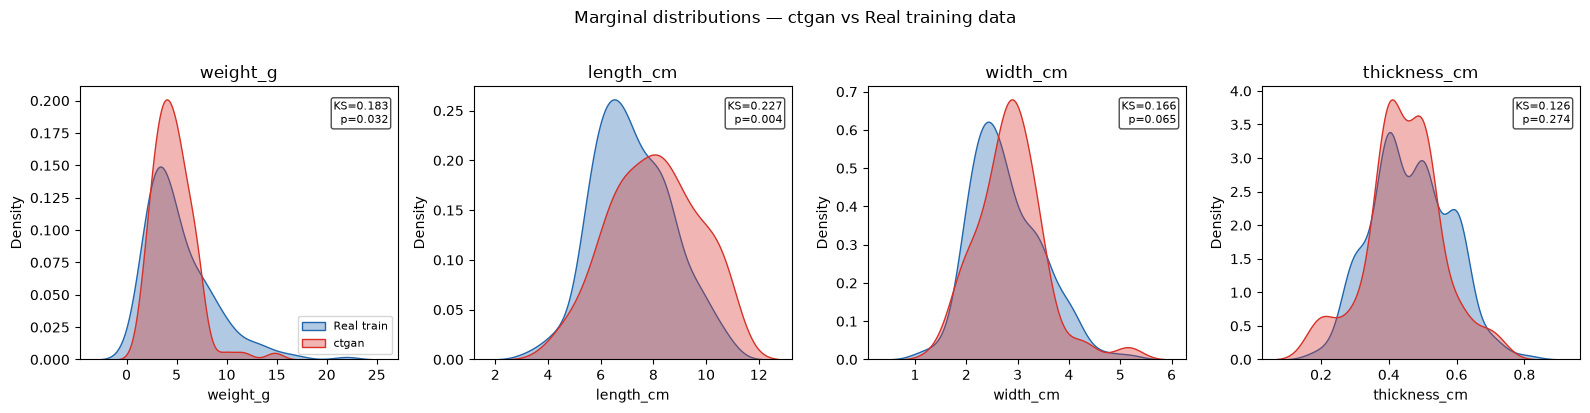


ctgan — KS statistics:
  weight_g         KS=0.183  p=0.032  Δmean=-0.5972
  length_cm        KS=0.227  p=0.004  Δmean=+0.7941
  width_cm         KS=0.166  p=0.065  Δmean=+0.0717
  thickness_cm     KS=0.126  p=0.274  Δmean=-0.0195
  Saved: results/figures/fig_univariate_tvae.png


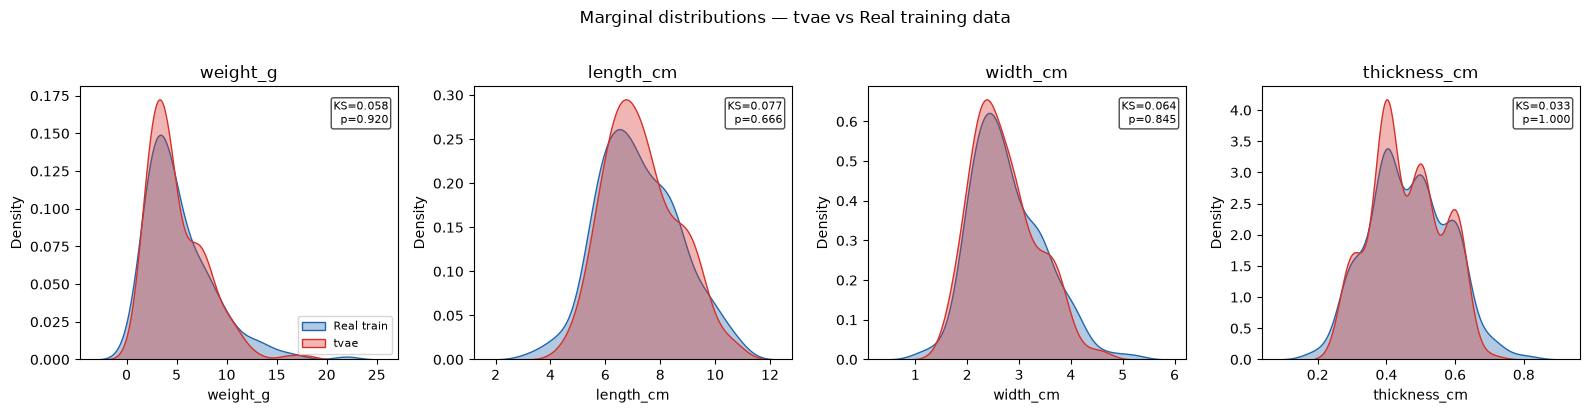


tvae — KS statistics:
  weight_g         KS=0.058  p=0.920  Δmean=-0.2790
  length_cm        KS=0.077  p=0.666  Δmean=+0.0923
  width_cm         KS=0.064  p=0.845  Δmean=-0.0742
  thickness_cm     KS=0.033  p=1.000  Δmean=-0.0074


In [10]:
def univariate_fidelity_report(
    df_real: pd.DataFrame,
    df_synth: pd.DataFrame,
    synth_name: str,
    save_path: Path = None,
) -> dict:
    """
    Compare marginal distributions (real vs synthetic) for all four
    morphometric variables via KDE plots and KS statistics.

    The two-sample KS test is used as a descriptive tool, not as a
    decision criterion: with n=167 the test has moderate power and
    statistically significant differences may be practically negligible.
    Always interpret KS together with the Δmean and visual overlap.

    Parameters
    ----------
    df_real    : Real training data.
    df_synth   : Synthetic data (bio_valid rows only).
    synth_name : Model name — used in plot title and legend.
    save_path  : If provided, save the figure at this path (PNG, 150 dpi).

    Returns
    -------
    dict
        Per-variable statistics: real/synth mean, std, delta_mean, KS stat, KS p.
    """
    report = {}
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for ax, col in zip(axes, FEATURES_ALL):
        r = df_real[col].dropna().values
        s = df_synth[col].dropna().values

        ks_stat, ks_p = stats.ks_2samp(r, s)

        report[col] = {
            "real_mean":  r.mean(),
            "synth_mean": s.mean(),
            "real_std":   r.std(),
            "synth_std":  s.std(),
            "delta_mean": s.mean() - r.mean(),
            "ks_stat":    ks_stat,
            "ks_p":       ks_p,
        }

        sns.kdeplot(r, ax=ax, label="Real train", color="#2166ac", fill=True, alpha=0.35)
        sns.kdeplot(s, ax=ax, label=synth_name,   color="#d73027", fill=True, alpha=0.35)
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.text(
            0.97, 0.95,
            f"KS={ks_stat:.3f}\np={ks_p:.3f}",
            transform=ax.transAxes,
            ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7),
        )
        if ax == axes[0]:
            ax.legend(fontsize=8)

    fig.suptitle(
        f"Marginal distributions — {synth_name} vs Real training data",
        y=1.02, fontsize=12
    )
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")

    plt.show()
    return report


# ── Run for each synthesiser (prop=1.00, replica=0 as representative) ─────────
# prop=1.00 and replica=0 (seed=42) is used as the canonical comparison point.
# Variability across replicas is addressed in Sections 10 and 11.
fidelity_reports = {}

for synth_name in fitted.keys():
    ref_entry = next(
        e for e in synthetic_registry
        if e["model"] == synth_name
        and e["proportion"] == 1.00
        and e["replica"] == 0
    )
    df_valid = ref_entry["df"][ref_entry["df"]["bio_valid"]]

    report = univariate_fidelity_report(
        df_real    = df_train,
        df_synth   = df_valid,
        synth_name = synth_name,
        save_path  = FIGURES_DIR / f"fig_univariate_{synth_name}.png",
    )
    fidelity_reports[synth_name] = report

    print(f"\n{synth_name} — KS statistics:")
    for col, vals in report.items():
        print(f"  {col:15s}  KS={vals['ks_stat']:.3f}  p={vals['ks_p']:.3f}  "
              f"Δmean={vals['delta_mean']:+.4f}")

POOLED KS  (primary fidelity estimate — all valid replicas concatenated)
                              n_synth_pooled  ks_stat    ks_p  delta_mean
model           variable                                                 
gaussian_copula weight_g                 764   0.1878  0.0001      0.4601
                length_cm                764   0.1049  0.0900      0.1395
                width_cm                 764   0.1613  0.0014      0.0750
                thickness_cm             764   0.2343  0.0000      0.0119
ctgan           weight_g                 431   0.1668  0.0021     -0.6807
                length_cm                431   0.2015  0.0001      0.7287
                width_cm                 431   0.0853  0.3232     -0.0030
                thickness_cm             431   0.1643  0.0026     -0.0297
tvae            weight_g                 832   0.0532  0.8030     -0.2140
                length_cm                832   0.0530  0.8064      0.0674
                width_cm               

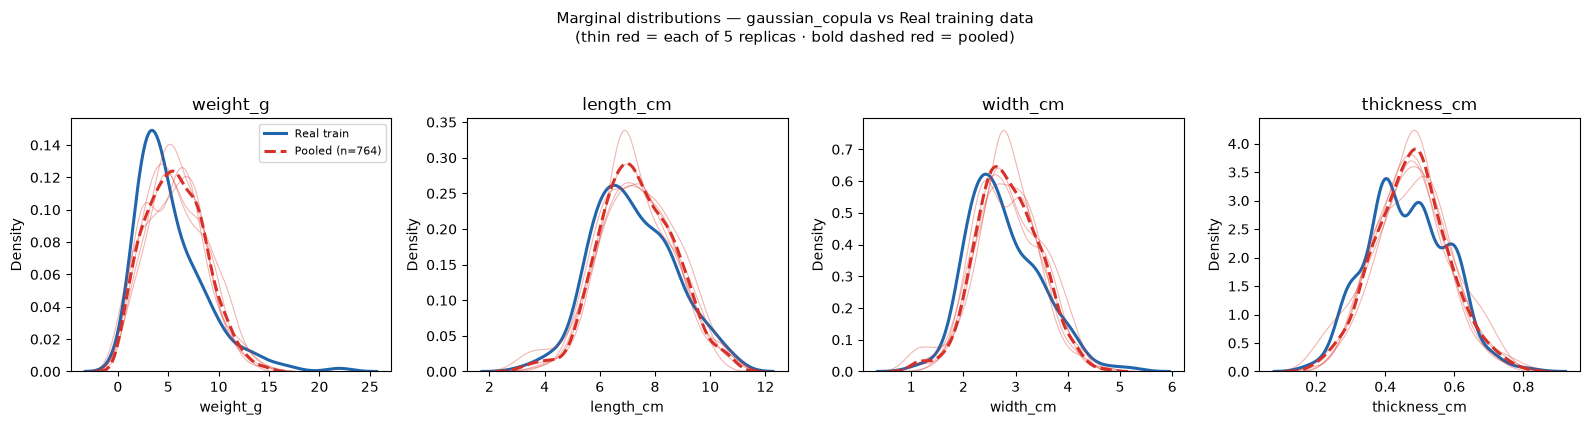

  Saved: results/figures/fig_univariate_pooled_ctgan.png


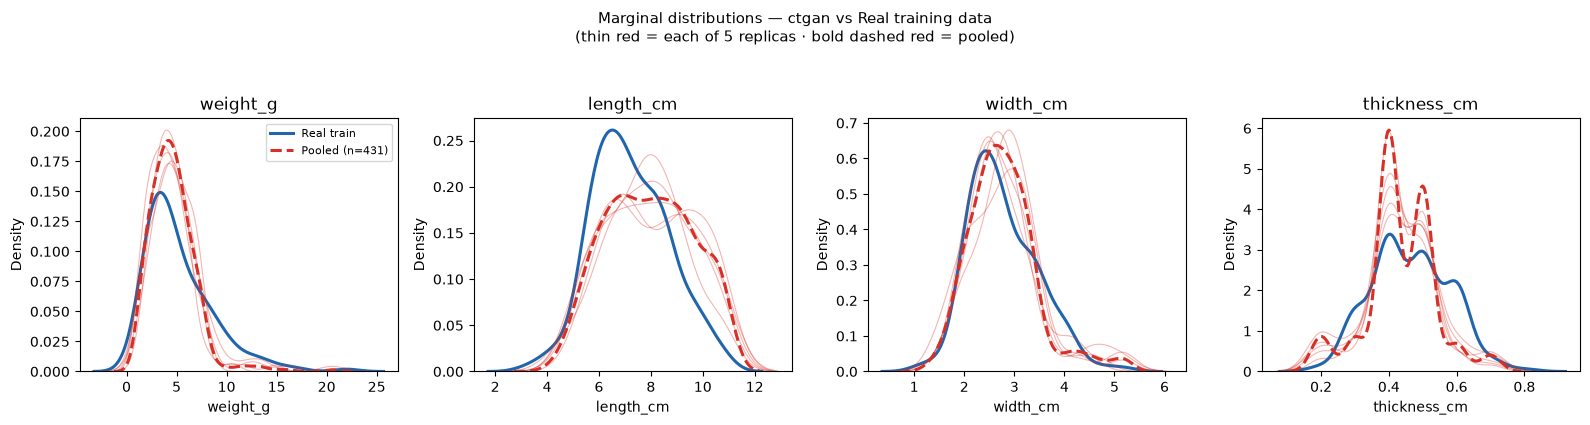

  Saved: results/figures/fig_univariate_pooled_tvae.png


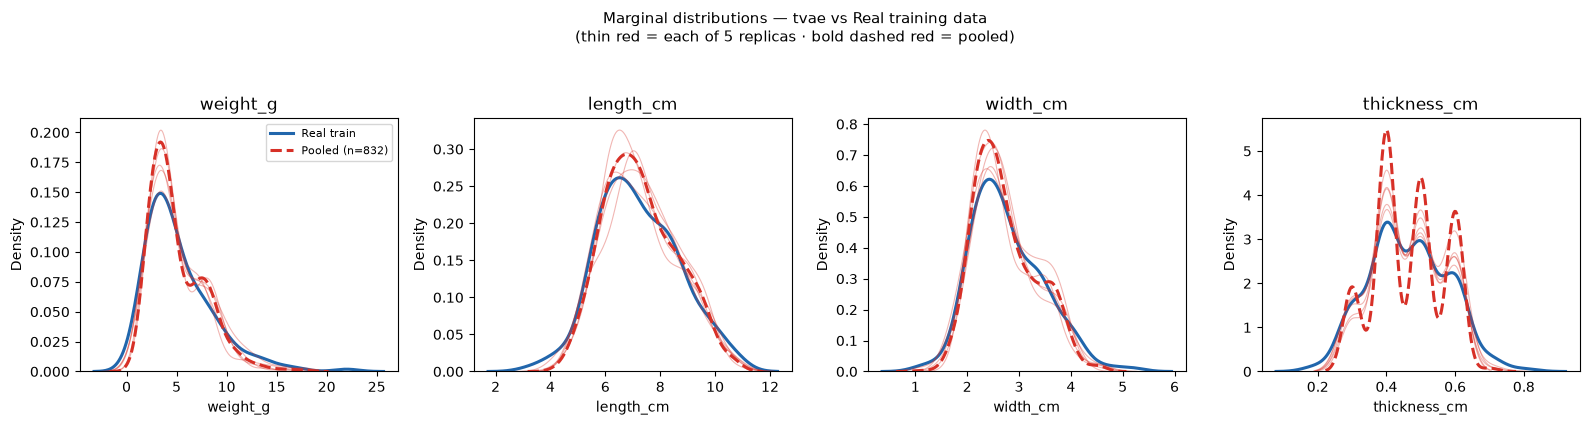

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# 8b · Univariate fidelity — replica-aggregated KS (pooled + per-replica)
# ─────────────────────────────────────────────────────────────────────────
# Paste as a NEW cell right after the existing §8 cell (id "b35855ca") in
# part2_synthetic_generation.ipynb. It does not replace the KDE plots from
# §8 — those remain a valid single-replica *visual* illustration — but it
# replaces the single-replica KS/Δmean numbers as the quantitative basis
# for any written conclusion (see the article's §5.1 discussion of why a
# single replica is not sufficient evidence on its own).
#
# It reports fidelity two complementary ways:
#   1. POOLED  — concatenate every valid replica's synthetic rows into one
#      larger sample and run a single KS test. This is the primary fidelity
#      estimate: it reduces Monte Carlo noise in the empirical synthetic
#      CDF and gives more statistical power than any single replica.
#   2. PER-REPLICA — run KS separately on each of the 5 replicas and report
#      the distribution (mean, std, min, max) across seeds, plus the
#      fraction of replicas that reach significance. This is a stability
#      diagnostic: a synthesiser whose KS/p swings wildly across seeds is
#      less trustworthy even if its pooled/average fidelity looks fine —
#      this matters especially for CTGAN, which §2.2 already flags as the
#      most seed-sensitive of the three.
#
# Limitation carried forward explicitly (do not silently drop it from the
# text): each synthesiser was fit ONCE (cell "753f5df0", RANDOM_STATE=42).
# The 5 replicas here vary only the *sampling* seed from that one fixed,
# already-trained generator — they do not capture variability from
# retraining with different seeds/initialisations, which for an
# adversarially-trained model like CTGAN could be a further, larger source
# of variance. That question is left to a dedicated sensitivity analysis
# (12_sensitivity_analysis.ipynb) that re-fits with multiple seeds.
# ═══════════════════════════════════════════════════════════════════════════

from typing import Sequence


def univariate_fidelity_replicated(
    df_real: pd.DataFrame,
    registry: list[dict],
    synth_name: str,
    proportion: float = 1.00,
    features: Sequence[str] = FEATURES_ALL,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compute univariate KS fidelity for one synthesiser at one augmentation
    proportion, aggregated across all its replicas.

    Parameters
    ----------
    df_real : pd.DataFrame
        Real training data (`df_train`).
    registry : list of dict
        `synthetic_registry` entries, each with keys 'model', 'proportion',
        'replica', 'seed', 'df' (the sampled+bio-checked dataframe).
    synth_name : str
        Which synthesiser to evaluate, e.g. 'gaussian_copula', 'ctgan', 'tvae'.
    proportion : float
        Which augmentation proportion's replicas to use (default: 1.00 = 100%,
        matching the reference used in the original §8 single-replica check).
    features : sequence of str
        Columns to test (default: FEATURES_ALL).

    Returns
    -------
    df_pooled : pd.DataFrame
        One row per variable — pooled KS statistic, p-value and Δmean
        computed on the concatenation of all valid replicas.
    df_per_replica : pd.DataFrame
        One row per (variable, replica) — individual KS statistic, p-value
        and Δmean, for the stability diagnostic.

    Raises
    ------
    ValueError
        If no registry entries match (synth_name, proportion), or if a
        requested feature is missing from df_real.
    """
    missing_cols = set(features) - set(df_real.columns)
    if missing_cols:
        raise ValueError(f"Columns not found in df_real: {missing_cols}")

    entries = [
        e for e in registry
        if e["model"] == synth_name and e["proportion"] == proportion
    ]
    if not entries:
        raise ValueError(
            f"No registry entries for model={synth_name!r}, proportion={proportion}"
        )

    real_vals_by_col = {col: df_real[col].dropna().values for col in features}

    per_replica_records = []
    pooled_synth_vals: dict[str, list[np.ndarray]] = {col: [] for col in features}

    for entry in entries:
        df_valid = entry["df"][entry["df"]["bio_valid"]]
        if len(df_valid) < 5:
            # Too few biologically-valid rows in this replica to test
            # meaningfully; skip but keep the gap visible via n_synth counts.
            continue
        for col in features:
            s_vals = df_valid[col].dropna().values
            r_vals = real_vals_by_col[col]
            ks_stat, ks_p = stats.ks_2samp(r_vals, s_vals)
            per_replica_records.append({
                "model": synth_name,
                "proportion": proportion,
                "replica": entry["replica"],
                "seed": entry["seed"],
                "variable": col,
                "n_synth": len(s_vals),
                "ks_stat": ks_stat,
                "ks_p": ks_p,
                "delta_mean": s_vals.mean() - r_vals.mean(),
            })
            pooled_synth_vals[col].append(s_vals)

    df_per_replica = pd.DataFrame(per_replica_records)

    pooled_records = []
    for col in features:
        if not pooled_synth_vals[col]:
            continue
        s_pooled = np.concatenate(pooled_synth_vals[col])
        r_vals = real_vals_by_col[col]
        ks_stat, ks_p = stats.ks_2samp(r_vals, s_pooled)
        pooled_records.append({
            "model": synth_name,
            "proportion": proportion,
            "variable": col,
            "n_real": len(r_vals),
            "n_synth_pooled": len(s_pooled),
            "n_replicas_pooled": len(pooled_synth_vals[col]),
            "ks_stat": ks_stat,
            "ks_p": ks_p,
            "delta_mean": s_pooled.mean() - r_vals.mean(),
        })
    df_pooled = pd.DataFrame(pooled_records)

    return df_pooled, df_per_replica


# ── Run for every synthesiser at the 100% proportion (same reference point
#    as the original §8 check, for direct comparability) ────────────────────
pooled_all, per_replica_all = [], []

for synth_name in fitted.keys():
    df_pooled, df_per_rep = univariate_fidelity_replicated(
        df_real=df_train,
        registry=synthetic_registry,
        synth_name=synth_name,
        proportion=1.00,
    )
    pooled_all.append(df_pooled)
    per_replica_all.append(df_per_rep)

df_pooled_all = pd.concat(pooled_all, ignore_index=True)
df_per_replica_all = pd.concat(per_replica_all, ignore_index=True)

# ── Stability summary across the 5 replicas ─────────────────────────────────
df_stability = (
    df_per_replica_all
    .groupby(["model", "variable"])
    .agg(
        ks_mean=("ks_stat", "mean"),
        ks_std=("ks_stat", "std"),
        ks_min=("ks_stat", "min"),
        ks_max=("ks_stat", "max"),
        delta_mean_mean=("delta_mean", "mean"),
        delta_mean_std=("delta_mean", "std"),
        frac_significant=("ks_p", lambda s: float((s < 0.05).mean())),
    )
    .round(4)
)

print("=" * 70)
print("POOLED KS  (primary fidelity estimate — all valid replicas concatenated)")
print("=" * 70)
print(
    df_pooled_all
    .set_index(["model", "variable"])[["n_synth_pooled", "ks_stat", "ks_p", "delta_mean"]]
    .round(4)
)

print("\n" + "=" * 70)
print("PER-REPLICA STABILITY  (mean ± std across the 5 seeds; frac_significant")
print("= share of the 5 replicas with p < 0.05 individually)")
print("=" * 70)
print(df_stability)

# ── Persist for traceability, same convention as the rest of the notebook ──
df_pooled_all.to_csv(METRICS_DIR / "univariate_ks_pooled.csv", index=False)
df_per_replica_all.to_csv(METRICS_DIR / "univariate_ks_per_replica.csv", index=False)
df_stability.reset_index().to_csv(METRICS_DIR / "univariate_ks_stability.csv", index=False)

print(f"\nSaved: {METRICS_DIR / 'univariate_ks_pooled.csv'}")
print(f"Saved: {METRICS_DIR / 'univariate_ks_per_replica.csv'}")
print(f"Saved: {METRICS_DIR / 'univariate_ks_stability.csv'}")


# ═══════════════════════════════════════════════════════════════════════════
# 8c · Companion plot — pooled + per-replica KDE overlay
# ─────────────────────────────────────────────────────────────────────────
# The single-replica KDE plots in §8 (function univariate_fidelity_report)
# are illustrative only: plotting one arbitrary replica risks visualising
# exactly the kind of artefact this section already retracted for CTGAN's
# weight_g (single-replica Δmean=-0.71 vs pooled Δmean=-0.12). This plot
# shows what the pooled/per-replica numbers above actually describe:
#   - real training KDE: solid, bold, blue
#   - each of the 5 individual replica KDEs: thin, semi-transparent, red
#     (visual read of replicate-to-replicate stability — tight bundle of
#     lines = stable, like TVAE; wide spread = unstable, like CTGAN's
#     weight_g)
#   - the pooled KDE across all valid replicas: bold, dashed, red
#     (matches the pooled KS statistic reported above)
# ═══════════════════════════════════════════════════════════════════════════

def plot_univariate_fidelity_pooled(
    df_real: pd.DataFrame,
    registry: list[dict],
    synth_name: str,
    proportion: float = 1.00,
    features: Sequence[str] = FEATURES_ALL,
    save_path: Path = None,
) -> None:
    """
    Plot real vs synthetic marginal densities for one synthesiser, showing
    both the pooled fidelity estimate and per-replica stability in one
    figure per variable.

    Parameters
    ----------
    df_real : pd.DataFrame
        Real training data (`df_train`).
    registry : list of dict
        `synthetic_registry` entries.
    synth_name : str
        Which synthesiser to plot.
    proportion : float
        Which augmentation proportion's replicas to use (default: 100%).
    features : sequence of str
        Columns to plot (default: FEATURES_ALL).
    save_path : Path, optional
        If given, the figure is saved to this path at 150 dpi.
    """
    entries = [
        e for e in registry
        if e["model"] == synth_name and e["proportion"] == proportion
    ]
    if not entries:
        raise ValueError(
            f"No registry entries for model={synth_name!r}, proportion={proportion}"
        )

    fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 4))
    if len(features) == 1:
        axes = [axes]

    for ax, col in zip(axes, features):
        r_vals = df_real[col].dropna().values
        sns.kdeplot(r_vals, ax=ax, color="#2166ac", linewidth=2.2, label="Real train")

        pooled_vals = []
        for entry in entries:
            df_valid = entry["df"][entry["df"]["bio_valid"]]
            if len(df_valid) < 5:
                continue
            s_vals = df_valid[col].dropna().values
            pooled_vals.append(s_vals)
            sns.kdeplot(s_vals, ax=ax, color="#d73027", linewidth=0.8, alpha=0.35)

        if pooled_vals:
            s_pooled = np.concatenate(pooled_vals)
            sns.kdeplot(
                s_pooled, ax=ax, color="#d73027", linewidth=2.2, linestyle="--",
                label=f"Pooled (n={len(s_pooled)})",
            )

        ax.set_title(col)
        ax.set_xlabel(col)
        if ax is axes[0]:
            ax.legend(fontsize=8)

    fig.suptitle(
        f"Marginal distributions — {synth_name} vs Real training data\n"
        f"(thin red = each of {len(entries)} replicas · bold dashed red = pooled)",
        y=1.05, fontsize=11,
    )
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")

    plt.show()


# ── Run for every synthesiser ────────────────────────────────────────────
for synth_name in fitted.keys():
    plot_univariate_fidelity_pooled(
        df_real=df_train,
        registry=synthetic_registry,
        synth_name=synth_name,
        proportion=1.00,
        save_path=FIGURES_DIR / f"fig_univariate_pooled_{synth_name}.png",
    )

---
## 9 · Multivariate fidelity — correlation matrices

  Saved: results/figures/fig_corr_pearson_gaussian_copula.png


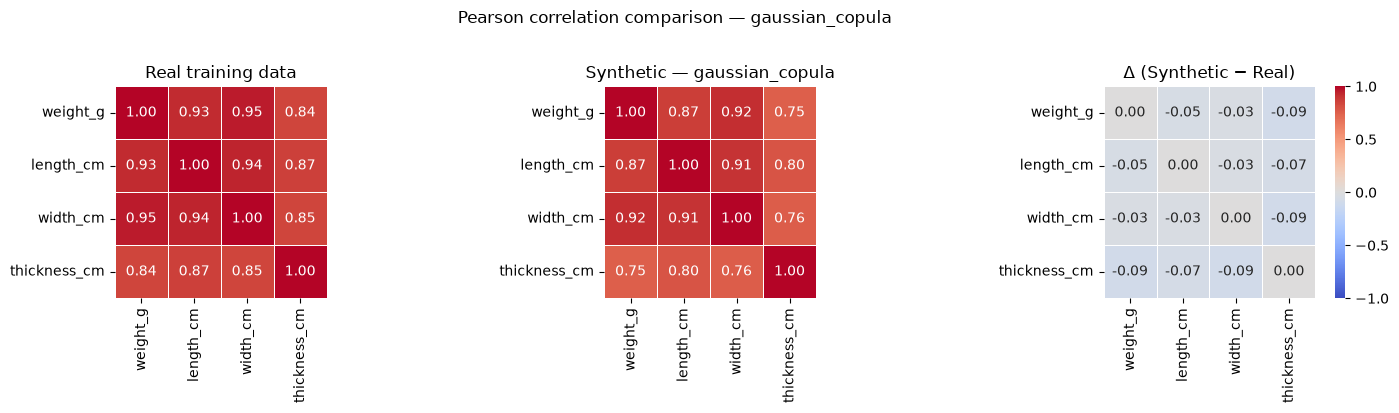

Max |Δ| for gaussian_copula: 0.0891
  Saved: results/figures/fig_corr_pearson_ctgan.png


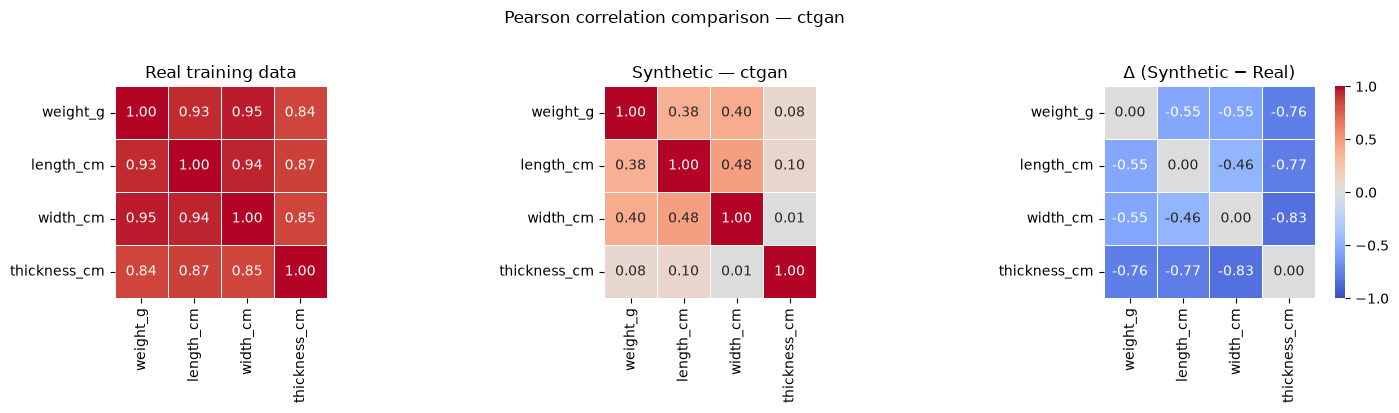

Max |Δ| for ctgan: 0.8330
  Saved: results/figures/fig_corr_pearson_tvae.png


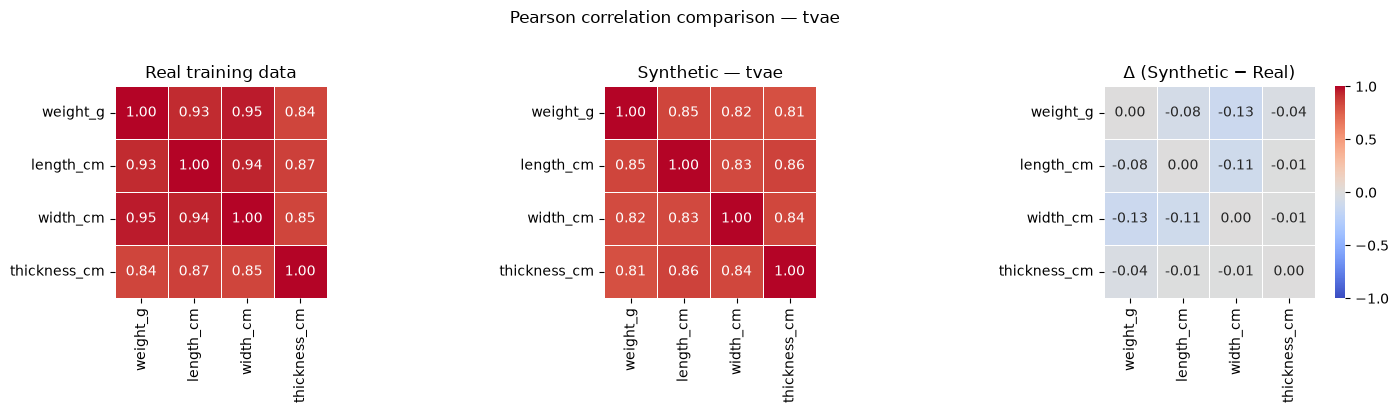

Max |Δ| for tvae: 0.1301


In [12]:
# =========================================================================
# Three-panel heatmap: real correlations | synthetic correlations | delta.
#
#    The delta matrix (synthetic − real) highlights which variable pairs
#    are most affected by the generative model.  Large absolute deltas
#    in the weight-dimension pairs indicate poor allometric preservation.
#
#    Parameters
#   ----------
#    df_real    : Real training data.
#    df_synth   : Synthetic data (bio_valid rows only).
#    synth_name : Model name — used in plot title.
#    method     : Correlation method ('pearson' or 'spearman').
#   save_path  : If provided, save the figure at this path (PNG, 150 dpi).
#
#   Returns
#    -------
#    pd.DataFrame
#        Delta matrix (synthetic − real), shape (4, 4).
# -------------------------------------------------------------------------

def correlation_delta_heatmap(
    df_real: pd.DataFrame,
    df_synth: pd.DataFrame,
    synth_name: str,
    method: str = "pearson",
    save_path: Path = None,
) -> pd.DataFrame:
    corr_real  = df_real[FEATURES_ALL].corr(method=method)
    corr_synth = df_synth[FEATURES_ALL].corr(method=method)
    delta      = corr_synth - corr_real

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    hm_kw = dict(
        vmin=-1, vmax=1, annot=True, fmt=".2f",
        cmap="coolwarm", square=True, linewidths=0.5
    )

    sns.heatmap(corr_real,  ax=axes[0], cbar=False, **hm_kw)
    axes[0].set_title("Real training data")

    sns.heatmap(corr_synth, ax=axes[1], cbar=False, **hm_kw)
    axes[1].set_title(f"Synthetic — {synth_name}")

    sns.heatmap(delta, ax=axes[2], **hm_kw)
    axes[2].set_title("Δ (Synthetic − Real)")

    fig.suptitle(
        f"{method.capitalize()} correlation comparison — {synth_name}",
        y=1.02, fontsize=12
    )
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")

    plt.show()
    return delta


# ── Run for each synthesiser ───────────────────────────────────────────────────
for synth_name in fitted.keys():
    ref_entry = next(
        e for e in synthetic_registry
        if e["model"] == synth_name and e["proportion"] == 1.00 and e["replica"] == 0
    )
    df_valid = ref_entry["df"][ref_entry["df"]["bio_valid"]]

    delta = correlation_delta_heatmap(
        df_real    = df_train,
        df_synth   = df_valid,
        synth_name = synth_name,
        method     = "pearson",
        save_path  = FIGURES_DIR / f"fig_corr_pearson_{synth_name}.png",
    )
    # Max |Δ| excluding the diagonal (self-correlation = 1 always)
    max_delta = delta.abs().values[~np.eye(4, dtype=bool)].max()
    print(f"Max |Δ| for {synth_name}: {max_delta:.4f}")

  Saved: results/figures/fig_corr_pooled_gaussian_copula.png


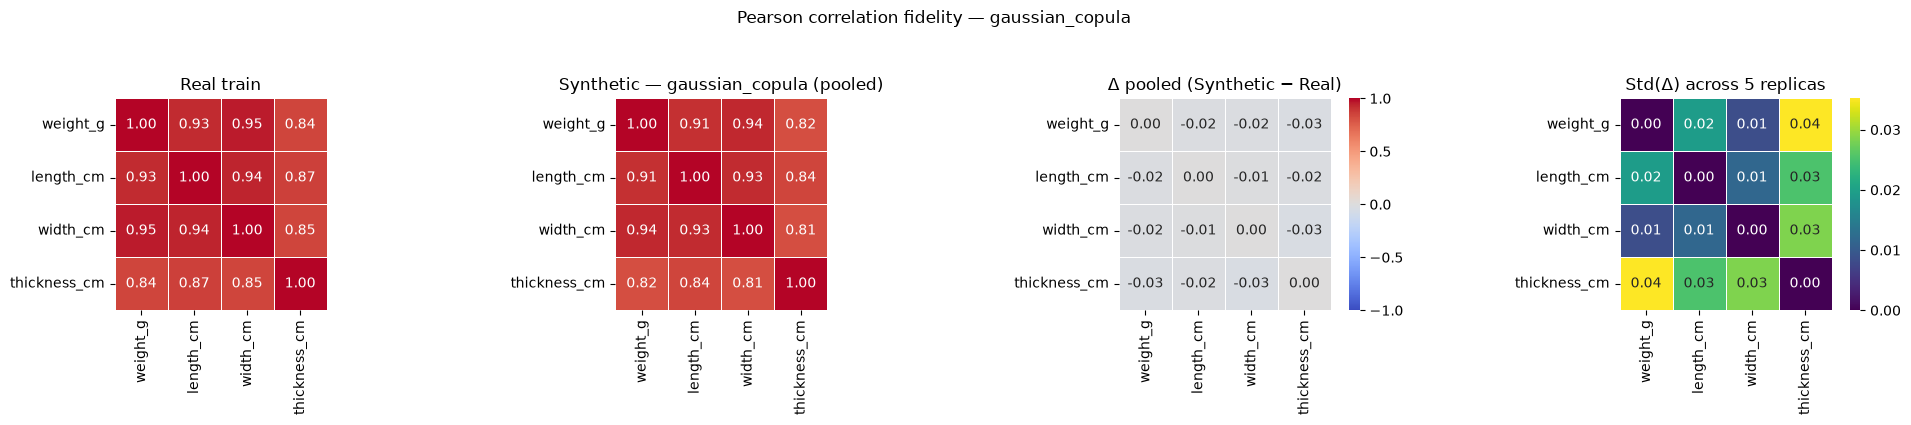

  Saved: results/figures/fig_corr_pooled_ctgan.png


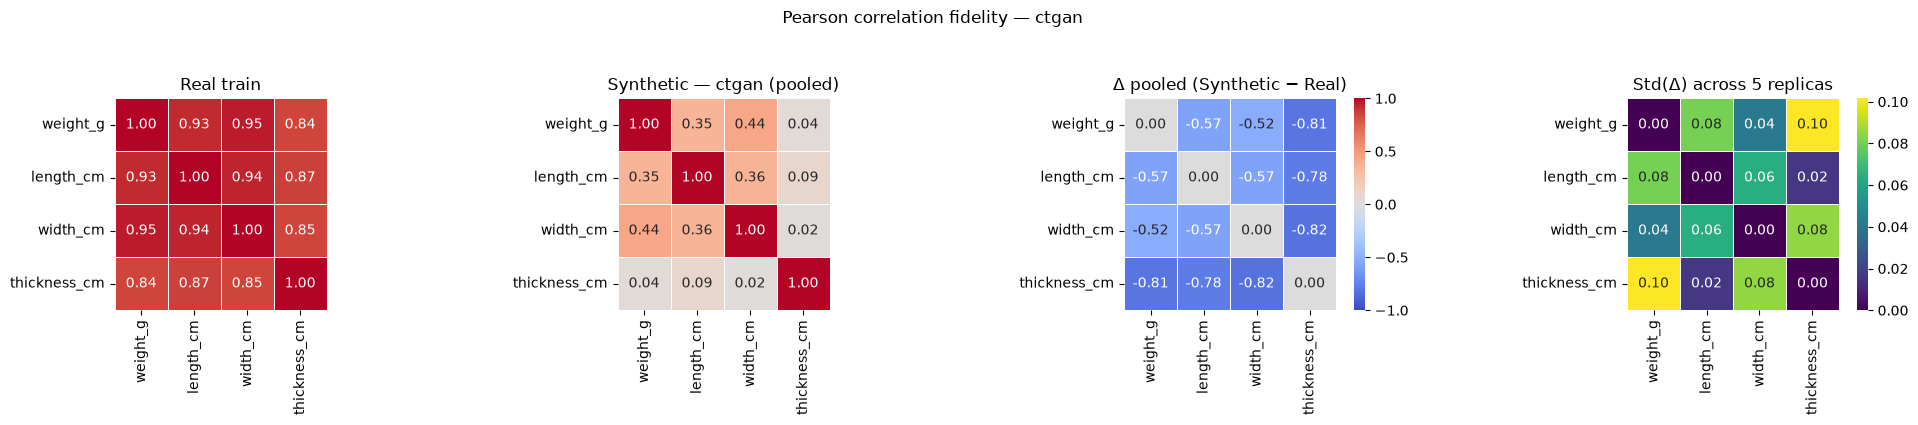

  Saved: results/figures/fig_corr_pooled_tvae.png


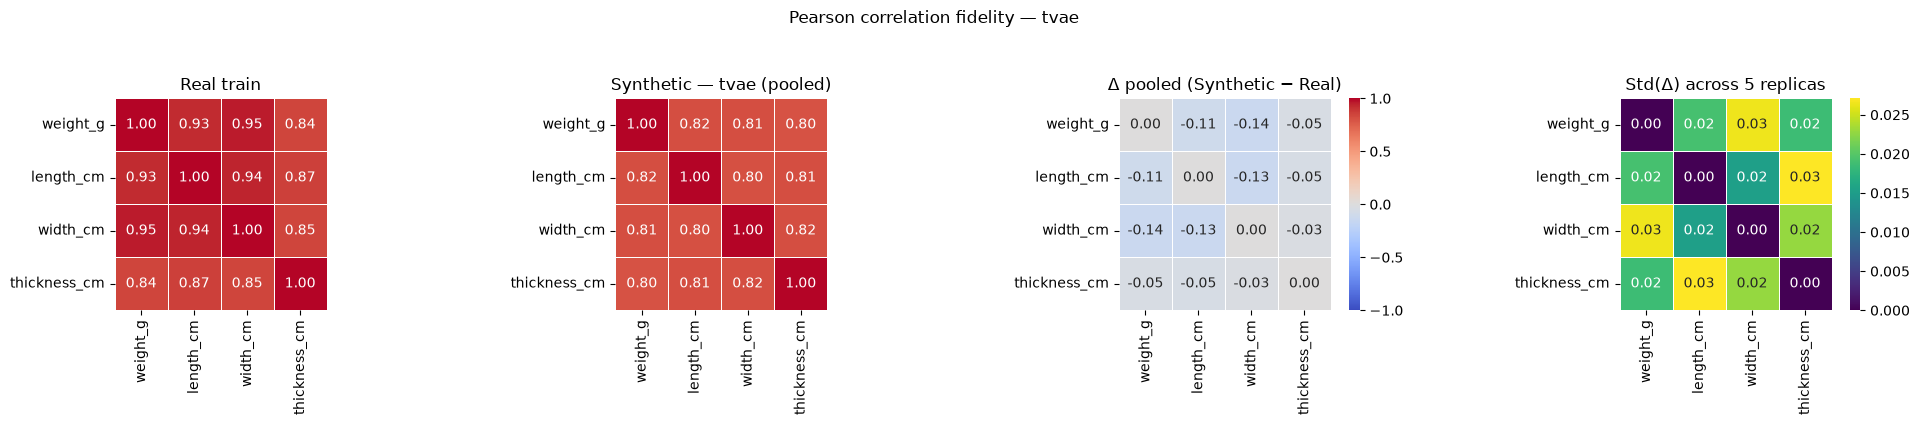

Correlation fidelity summary (off-diagonal pairs only):
             model  max_abs_delta_pooled  max_std_delta_replicas
0  gaussian_copula                0.0315                  0.0352
1            ctgan                0.8230                  0.1016
2             tvae                0.1389                  0.0271


In [14]:
# ═════════════════════════════════════════════════════════════════════════
# 9b · Correlation fidelity — pooled + per-replica stability
# ─────────────────────────────────────────────────────────────────────────


import numpy as np
import pandas as pd


def correlation_delta_replicated(
    df_real: pd.DataFrame,
    registry: list[dict],
    synth_name: str,
    proportion: float = 1.00,
    features: list[str] = FEATURES_ALL,
    method: str = "pearson",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, list[pd.DataFrame]]:
    """
    Compare real vs synthetic correlation structure for one synthesiser,
    aggregated across all its replicas at one proportion.

    Returns
    -------
    corr_real : pd.DataFrame
        Correlation matrix of the real training data.
    delta_pooled : pd.DataFrame
        corr(synthetic_pooled) - corr(real): the primary fidelity estimate,
        computed on every valid replica's rows concatenated together.
    delta_std : pd.DataFrame
        Element-wise standard deviation of the per-replica delta matrices —
        a stability diagnostic, analogous to Table 5.1b's ks_std.
    per_replica_deltas : list of pd.DataFrame
        One delta matrix per valid replica, for inspection.
    """
    entries = [e for e in registry if e["model"] == synth_name and e["proportion"] == proportion]
    if not entries:
        raise ValueError(f"No registry entries for model={synth_name!r}, proportion={proportion}")

    corr_real = df_real[features].corr(method=method)

    valid_dfs = [e["df"][e["df"]["bio_valid"]] for e in entries]
    valid_dfs = [d for d in valid_dfs if len(d) >= 5]
    if not valid_dfs:
        raise ValueError(f"No replica of {synth_name!r} has ≥5 biologically-valid rows")

    df_pooled = pd.concat(valid_dfs, ignore_index=True)
    corr_pooled = df_pooled[features].corr(method=method)
    delta_pooled = corr_pooled - corr_real

    per_replica_deltas = [d[features].corr(method=method) - corr_real for d in valid_dfs]
    stacked = np.stack([d.values for d in per_replica_deltas])
    delta_std = pd.DataFrame(stacked.std(axis=0), index=features, columns=features)

    return corr_real, delta_pooled, delta_std, per_replica_deltas


def plot_correlation_delta_pooled(
    df_real: pd.DataFrame,
    registry: list[dict],
    synth_name: str,
    proportion: float = 1.00,
    features: list[str] = FEATURES_ALL,
    method: str = "pearson",
    save_path: Path = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Four-panel figure: real correlations | pooled synthetic correlations |
    Δ pooled (synthetic - real) | Std(Δ) across replicas. The last panel
    makes replicate instability visible in the same figure as the fidelity
    estimate, rather than requiring a second plot.
    """
    corr_real, delta_pooled, delta_std, per_replica_deltas = correlation_delta_replicated(
        df_real, registry, synth_name, proportion, features, method,
    )
    n_replicas = len(per_replica_deltas)
    corr_pooled = corr_real + delta_pooled

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    hm_kw = dict(annot=True, fmt=".2f", square=True, linewidths=0.5)

    sns.heatmap(corr_real, ax=axes[0], vmin=-1, vmax=1, cmap="coolwarm", cbar=False, **hm_kw)
    axes[0].set_title("Real train")

    sns.heatmap(corr_pooled, ax=axes[1], vmin=-1, vmax=1, cmap="coolwarm", cbar=False, **hm_kw)
    axes[1].set_title(f"Synthetic — {synth_name} (pooled)")

    sns.heatmap(delta_pooled, ax=axes[2], vmin=-1, vmax=1, cmap="coolwarm", **hm_kw)
    axes[2].set_title("Δ pooled (Synthetic − Real)")

    vmax_std = max(delta_std.values.max(), 1e-6)
    sns.heatmap(delta_std, ax=axes[3], vmin=0, vmax=vmax_std, cmap="viridis", **hm_kw)
    axes[3].set_title(f"Std(Δ) across {n_replicas} replicas")

    fig.suptitle(f"{method.capitalize()} correlation fidelity — {synth_name}", y=1.05, fontsize=12)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved: {save_path}")
    plt.show()

    return delta_pooled, delta_std


# ── Run for every synthesiser; build a compact numeric summary ─────────────
corr_summary_records = []
for synth_name in fitted.keys():
    delta_pooled, delta_std = plot_correlation_delta_pooled(
        df_real=df_train,
        registry=synthetic_registry,
        synth_name=synth_name,
        proportion=1.00,
        save_path=FIGURES_DIR / f"fig_corr_pooled_{synth_name}.png",
    )
    off_diag = ~np.eye(len(FEATURES_ALL), dtype=bool)
    corr_summary_records.append({
        "model": synth_name,
        "max_abs_delta_pooled": float(np.abs(delta_pooled.values[off_diag]).max()),
        "max_std_delta_replicas": float(delta_std.values[off_diag].max()),
    })

df_corr_summary = pd.DataFrame(corr_summary_records)
print("Correlation fidelity summary (off-diagonal pairs only):")
print(df_corr_summary.round(4))
df_corr_summary.to_csv(METRICS_DIR / "correlation_fidelity_summary.csv", index=False)

---
## 10 · Allometric coefficient stability

Refit log(W) = log(a) + b₁·log(L) + b₂·log(A) + b₃·log(E) on each
synthetic replica and compare the estimated exponents against the
real-data values: b₁ ≈ 1.621, b₂ ≈ 0.876, b₃ ≈ 0.393.

In [15]:
def fit_allometric_loglog(
    df: pd.DataFrame,
    features: list = FEATURES,
    target: str = TARGET,
) -> dict:
    """
    Fit the multivariate allometric log-log model via OLS:

        log(W) = log(a) + b1·log(L) + b2·log(A) + b3·log(E)

    Estimation is performed in log-log space where the relationship is
    linear.  Back-transforming introduces a retransformation bias; this
    is corrected in Section 11 via the Duan smearing estimator.

    Parameters
    ----------
    df       : DataFrame with raw (non-log) morphometric variables.
    features : Predictor column names (default: FEATURES).
    target   : Response column name (default: TARGET = 'weight_g').

    Returns
    -------
    dict
        log_a, a=exp(log_a), per-feature exponents (b_<col>),
        R² in log-log space, sample size n.
    """
    X = np.log(df[features].values)
    y = np.log(df[target].values)
    model = LinearRegression().fit(X, y)

    coefs = {f"b_{f}": c for f, c in zip(features, model.coef_)}
    coefs["log_a"]     = model.intercept_
    coefs["a"]         = np.exp(model.intercept_)
    coefs["R2_loglog"] = model.score(X, y)
    coefs["n"]         = len(df)
    return coefs


# ── Fit on real training data (reference) ─────────────────────────────────────
ref_coefs = fit_allometric_loglog(df_train)
print("Reference (real training data):")
for k, v in ref_coefs.items():
    print(f"  {k:20s} {v:.4f}")

# ── Fit on every synthetic replica ────────────────────────────────────────────
# Replicas with fewer than 20 valid rows are skipped to avoid highly
# unstable OLS fits in log-log space.
coef_records = [{
    "source":     "real_train",
    "proportion": float("nan"),
    "replica":    float("nan"),
    **ref_coefs
}]

for entry in synthetic_registry:
    df_valid = entry["df"][entry["df"]["bio_valid"]]
    if len(df_valid) < 20:
        continue
    coefs = fit_allometric_loglog(df_valid)
    coef_records.append({
        "source":     entry["model"],
        "proportion": entry["proportion"],
        "replica":    entry["replica"],
        **coefs,
    })

df_coefs = pd.DataFrame(coef_records)

b_cols = ["b_length_cm", "b_width_cm", "b_thickness_cm"]
print("\nAllometric exponents by synthesiser (mean ± std across all proportions and replicas):")
print(
    df_coefs.groupby("source")[b_cols]
    .agg(["mean", "std"])
    .round(4)
)

df_coefs.to_csv(METRICS_DIR / "allometric_coefs_synthetic.csv", index=False)
print("\nSaved to results/metrics/allometric_coefs_synthetic.csv")

Reference (real training data):
  b_length_cm          1.6210
  b_width_cm           0.8759
  b_thickness_cm       0.3933
  log_a                -2.2540
  a                    0.1050
  R2_loglog            0.9816
  n                    167.0000

Allometric exponents by synthesiser (mean ± std across all proportions and replicas):
                b_length_cm         b_width_cm         b_thickness_cm        
                       mean     std       mean     std           mean     std
source                                                                       
ctgan                0.6257  0.3533     0.7853  0.3389         0.0699  0.3268
gaussian_copula      0.6521  0.8018     1.9689  0.4364         0.1733  0.3335
real_train           1.6210     NaN     0.8759     NaN         0.3933     NaN
tvae                 1.2373  0.2729     0.7553  0.2057         0.7375  0.2671

Saved to results/metrics/allometric_coefs_synthetic.csv


In [16]:
# ═════════════════════════════════════════════════════════════════════════
# Allometric exponent stability, fixed at one proportion
# ─────────────────────────────────────────────────────────────────────────

import pandas as pd


def allometric_coefs_replicated(
    df_real: pd.DataFrame,
    registry: list[dict],
    proportion: float = 1.00,
    features: list[str] = FEATURES,
    target: str = TARGET,
    min_valid_rows: int = 20,
) -> tuple[dict, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Refit the log-log allometric model on each replica of each synthesiser
    at a FIXED proportion (default 100%, matching §5.1/§5.3), and summarise
    exponent stability across the resulting 5 replicas per model.

    Requires `fit_allometric_loglog` to already be defined (§10 cell).

    Returns
    -------
    ref_coefs : dict
        Allometric fit on real training data (the reference point).
    df_coefs : pd.DataFrame
        One row per (model, replica) that passed the filter.
    df_summary : pd.DataFrame
        Mean, std and count of each exponent per model, across replicas.
    df_excluded : pd.DataFrame
        Replicas dropped for having fewer than `min_valid_rows` valid rows.
    """
    ref_coefs = fit_allometric_loglog(df_real, features=features, target=target)

    records, excluded = [], []
    for entry in registry:
        if entry["proportion"] != proportion:
            continue
        df_valid = entry["df"][entry["df"]["bio_valid"]]
        if len(df_valid) < min_valid_rows:
            excluded.append({
                "model": entry["model"], "replica": entry["replica"], "n_valid": len(df_valid),
            })
            continue
        coefs = fit_allometric_loglog(df_valid, features=features, target=target)
        records.append({
            "model": entry["model"], "replica": entry["replica"], "n_valid": len(df_valid), **coefs,
        })

    df_coefs = pd.DataFrame(records)
    df_excluded = pd.DataFrame(excluded)

    b_cols = [f"b_{f}" for f in features]
    df_summary = df_coefs.groupby("model")[b_cols].agg(["mean", "std", "count"]).round(4)

    return ref_coefs, df_coefs, df_summary, df_excluded


ref_coefs, df_coefs_p100, df_allometric_summary, df_excluded_replicas = allometric_coefs_replicated(
    df_real=df_train, registry=synthetic_registry, proportion=1.00,
)

print("Reference (real training data):")
for k in ["b_length_cm", "b_width_cm", "b_thickness_cm"]:
    print(f"  {k:15s} {ref_coefs[k]:.4f}")

print("\nAllometric exponent stability at 100% proportion (mean ± std ± n replicas):")
print(df_allometric_summary)

if len(df_excluded_replicas):
    print(f"\n{len(df_excluded_replicas)} replica(s) excluded (fewer than 20 valid rows):")
    print(df_excluded_replicas)
else:
    print("\nNo replicas excluded at this proportion.")

df_coefs_p100.to_csv(METRICS_DIR / "allometric_coefs_p100_by_replica.csv", index=False)
df_allometric_summary.to_csv(METRICS_DIR / "allometric_coefs_p100_summary.csv")

Reference (real training data):
  b_length_cm     1.6210
  b_width_cm      0.8759
  b_thickness_cm  0.3933

Allometric exponent stability at 100% proportion (mean ± std ± n replicas):
                b_length_cm               b_width_cm                \
                       mean     std count       mean     std count   
model                                                                
ctgan                0.5722  0.2382     5     0.6828  0.2628     5   
gaussian_copula      0.6238  0.2786     5     1.9220  0.2479     5   
tvae                 1.1334  0.2486     5     0.7240  0.1268     5   

                b_thickness_cm                
                          mean     std count  
model                                         
ctgan                   0.0319  0.0730     5  
gaussian_copula         0.3186  0.3228     5  
tvae                    0.7308  0.0592     5  

No replicas excluded at this proportion.


### Visualise exponent distributions

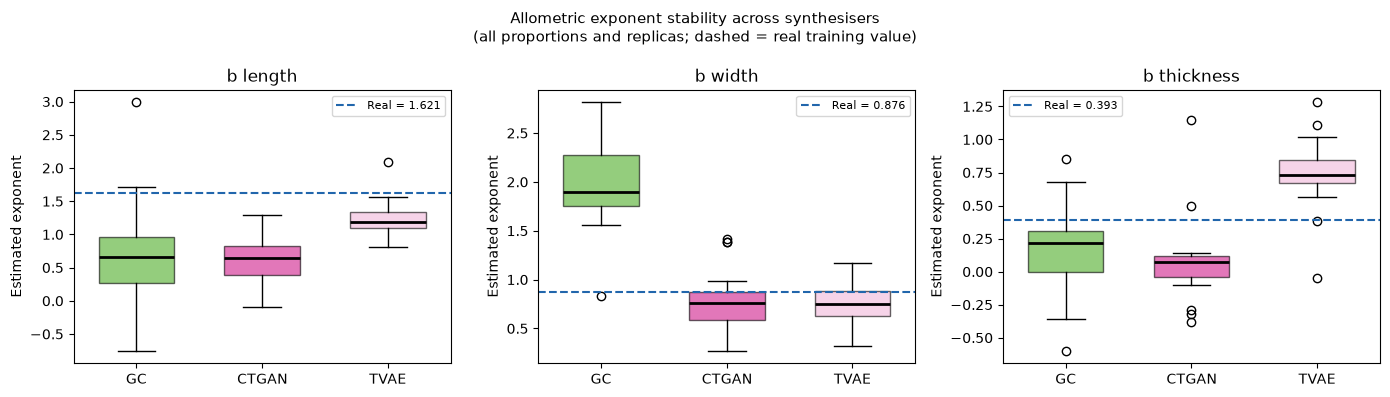

Saved: results/figures/fig_allometric_stability.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

synth_names = ["gaussian_copula", "ctgan", "tvae"]
colors      = {"gaussian_copula": "#4dac26", "ctgan": "#d01c8b", "tvae": "#f1b6da"}

# One box per synthesiser per exponent.
# The dashed horizontal line marks the exponent estimated on real training data.
# A well-behaved synthesiser should produce a narrow box centred near the dashed line.
for ax, b_col, real_val in zip(
    axes,
    ["b_length_cm", "b_width_cm", "b_thickness_cm"],
    [1.621, 0.876, 0.393],
):
    for sname in synth_names:
        vals = df_coefs[df_coefs["source"] == sname][b_col].dropna()
        ax.boxplot(
            vals,
            positions=[synth_names.index(sname)],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=colors[sname], alpha=0.6),
            medianprops=dict(color="black", linewidth=2),
        )
    ax.axhline(
        real_val, color="#2166ac", linestyle="--", linewidth=1.5,
        label=f"Real = {real_val:.3f}"
    )
    ax.set_xticks(range(3))
    ax.set_xticklabels(["GC", "CTGAN", "TVAE"])
    ax.set_title(b_col.replace("b_", "b ").replace("_cm", ""))
    ax.set_ylabel("Estimated exponent")
    ax.legend(fontsize=8)

fig.suptitle(
    "Allometric exponent stability across synthesisers\n"
    "(all proportions and replicas; dashed = real training value)",
    fontsize=11
)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_allometric_stability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/fig_allometric_stability.png")

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# 10d · Testing the multicollinearity-amplification hypothesis
# ─────────────────────────────────────────────────────────────────────────
# Paste as a NEW cell directly after 10c (allometric_coefs_replicated.py).
# Requires `fit_allometric_loglog`, `df_train`, `synthetic_registry`,
# `FEATURES`, `TARGET` already defined (§10 and earlier).
#
# §5.2's "Reading the results" raises a hypothesis, not yet confirmed:
# GaussianCopula has the SMALLEST pooled correlation deviation of the
# three synthesisers (Table 5.2a, 0.032) but the SINGLE most distorted
# allometric exponent (b_width_cm = 1.922 vs real 0.876, Table 5.2b).
# `length_cm`, `width_cm` and `thickness_cm` are highly correlated in real
# fish; a log-log OLS fit on near-collinear predictors can have unstable
# per-coefficient estimates even when the overall correlation structure —
# and the fit's R² — barely move. This cell checks that directly:
#
#   1. R²_loglog per replica (already computed by fit_allometric_loglog,
#      but dropped from the 10c summary table) — if R² stays close to the
#      real-data value despite the coefficient swings, that supports a
#      coefficient-attribution artefact rather than genuine information
#      loss; if R² also drops, the distortion is real, not just a
#      collinearity artefact.
#   2. Variance inflation factors (VIF) for [log L, log W, log T] on real
#      vs. each synthesiser's pooled valid rows — higher VIF than real
#      data would mean the synthetic predictors are MORE collinear than
#      real ones, which independently amplifies coefficient instability
#      regardless of what Table 5.2a's aggregate correlation delta shows
#      (a summary statistic like max|Δ| does not fully capture a
#      multivariate collinearity structure).
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


def compute_vif(X: np.ndarray, feature_names: list[str]) -> dict:
    """
    Variance inflation factors without the statsmodels dependency:
    VIF_i = 1 / (1 - R2_i), where R2_i is the R² of regressing predictor i
    on the other predictors via plain OLS (sklearn's LinearRegression,
    already used throughout this notebook — no new dependency needed).

    A VIF of 1 means no collinearity; conventional rules of thumb flag
    VIF > 5 (moderate) or > 10 (severe) collinearity. Perfect collinearity
    (R2_i == 1) returns np.inf rather than raising a division error.
    """
    vif = {}
    for i, feat in enumerate(feature_names):
        y_i = X[:, i]
        X_others = np.delete(X, i, axis=1)
        r2_i = LinearRegression().fit(X_others, y_i).score(X_others, y_i)
        vif[feat] = float(1.0 / (1.0 - r2_i)) if r2_i < 1.0 else float("inf")
    return vif


def r2_and_vif_by_model(
    df_real: pd.DataFrame,
    registry: list[dict],
    proportion: float = 1.00,
    features: list[str] = FEATURES,
    target: str = TARGET,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    For real training data and each synthesiser's pooled valid replicas
    (at one proportion): R² of the log-log allometric fit, and VIF of
    each log-transformed predictor.

    Returns
    -------
    df_r2 : pd.DataFrame
        One row per replica (plus one row for real_train), with R2_loglog.
    df_vif : pd.DataFrame
        One row per source (real_train + each synthesiser, pooled), with
        one VIF column per feature.
    """
    r2_records = [{"source": "real_train", "replica": np.nan,
                    "R2_loglog": fit_allometric_loglog(df_real, features, target)["R2_loglog"]}]

    pooled_by_model: dict[str, list[pd.DataFrame]] = {}
    for entry in registry:
        if entry["proportion"] != proportion:
            continue
        df_valid = entry["df"][entry["df"]["bio_valid"]]
        if len(df_valid) < 20:
            continue
        coefs = fit_allometric_loglog(df_valid, features, target)
        r2_records.append({"source": entry["model"], "replica": entry["replica"], "R2_loglog": coefs["R2_loglog"]})
        pooled_by_model.setdefault(entry["model"], []).append(df_valid)

    df_r2 = pd.DataFrame(r2_records)

    def _vif_row(df: pd.DataFrame, source: str) -> dict:
        X = np.log(df[features].values)
        row = {"source": source, "n": len(df)}
        for feat, vif_val in compute_vif(X, features).items():
            row[f"vif_{feat}"] = vif_val
        return row

    vif_records = [_vif_row(df_real, "real_train")]
    for model, dfs in pooled_by_model.items():
        vif_records.append(_vif_row(pd.concat(dfs, ignore_index=True), model))
    df_vif = pd.DataFrame(vif_records)

    return df_r2, df_vif


df_r2, df_vif = r2_and_vif_by_model(df_train, synthetic_registry, proportion=1.00)

print("R²_loglog — real (single value) vs. per-replica synthetic (5 per model):")
print(df_r2.groupby("source")["R2_loglog"].agg(["mean", "std", "min", "max"]).round(4))

print("\nVariance inflation factors — real (n=167) vs. pooled synthetic (100% proportion):")
print(df_vif.round(2))

df_r2.to_csv(METRICS_DIR / "allometric_r2_p100.csv", index=False)
df_vif.to_csv(METRICS_DIR / "allometric_vif_p100.csv", index=False)

R²_loglog — real (single value) vs. per-replica synthetic (5 per model):
                   mean     std     min     max
source                                         
ctgan            0.2559  0.0374  0.2063  0.2877
gaussian_copula  0.8667  0.0355  0.8169  0.9091
real_train       0.9816     NaN  0.9816  0.9816
tvae             0.8064  0.0338  0.7484  0.8365

Variance inflation factors — real (n=167) vs. pooled synthetic (100% proportion):
            source    n  vif_length_cm  vif_width_cm  vif_thickness_cm
0       real_train  167          10.16          8.80              4.19
1  gaussian_copula  764           8.10          6.85              3.54
2            ctgan  431           1.17          1.17              1.01
3             tvae  832           3.58          3.73              3.85


---
## 11 · Preliminary TSTR benchmark

**TRTR**: train on real, validate on real (5-fold CV) — Part 1 reference.  
**TSTR**: train on synthetic (each replica), evaluate on the same real CV folds.  

> The sealed `real_test.parquet` is NOT used here.
> All evaluation is within the training set via cross-validation.

In [21]:
# ── Cross-validation setup ────────────────────────────────────────────────────
# The same KFold object and the same real arrays are reused for both TRTR and
# TSTR so that validation folds are identical across all comparisons.
KF = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_real = df_train[FEATURES].values
y_real = df_train[TARGET].values


def evaluate_allometric(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val:   np.ndarray,
    y_val:   np.ndarray,
) -> dict:
    """
    Fit a log-log OLS allometric model on (X_train, y_train) and predict
    on X_val in the original (non-log) scale using the Duan smearing
    correction to remove retransformation bias.

    Parameters
    ----------
    X_train, y_train : Training predictors and response (raw scale).
    X_val,   y_val   : Validation predictors and response (raw scale).

    Returns
    -------
    dict with MAE (g), R² and smearing factor for the fold.
    """
    # Fit in log-log space
    model   = LinearRegression().fit(np.log(X_train), np.log(y_train))
    # Duan 1983 smearing factor — corrects back-transformation bias
    log_res = np.log(y_train) - model.predict(np.log(X_train))
    smear   = np.mean(np.exp(log_res))

    y_pred = np.exp(model.predict(np.log(X_val))) * smear
    return {
        "MAE":   float(mean_absolute_error(y_val, y_pred)),
        "R2":    float(r2_score(y_val, y_pred)),
        "smear": float(smear),
    }


# ── TRTR baseline ─────────────────────────────────────────────────────────────
# Train and validate on real data only.  This is the reference against which
# all TSTR configurations will be compared in Section 11 and Part 3.
trtr_scores = [
    evaluate_allometric(X_real[tr], y_real[tr], X_real[va], y_real[va])
    for tr, va in KF.split(X_real)
]
df_trtr = pd.DataFrame(trtr_scores)
print("TRTR (real-only baseline):")
print(f"  MAE : {df_trtr['MAE'].mean():.4f} ± {df_trtr['MAE'].std():.4f} g")
print(f"  R²  : {df_trtr['R2'].mean():.4f} ± {df_trtr['R2'].std():.4f}")

trtr_mae_mean = df_trtr["MAE"].mean()
trtr_r2_mean  = df_trtr["R2"].mean()

TRTR (real-only baseline):
  MAE : 0.3522 ± 0.0834 g
  R²  : 0.9729 ± 0.0152


In [22]:
# ── TSTR per synthesiser and proportion ───────────────────────────────────────
# For each synthetic replica: train the allometric model on synthetic data only,
# then evaluate on the real validation folds (same folds as TRTR above).
# The outer loop iterates over all 60 replicas in synthetic_registry.
tstr_records = []

for entry in synthetic_registry:
    df_valid = entry["df"][entry["df"]["bio_valid"]]
    if len(df_valid) < 20:
        # Skip replicas with too few valid rows for stable log-log fitting.
        continue

    X_synth = df_valid[FEATURES].values
    y_synth = df_valid[TARGET].values

    # Train on the synthetic replica; validate on each real fold.
    # The validation indices (_, va) come from the same KF as TRTR,
    # ensuring fold-level comparability.
    fold_scores = [
        evaluate_allometric(X_synth, y_synth, X_real[va], y_real[va])
        for _, va in KF.split(X_real)
    ]
    df_fold = pd.DataFrame(fold_scores)

    tstr_records.append({
        "model":      entry["model"],
        "proportion": entry["proportion"],
        "replica":    entry["replica"],
        "MAE_mean":   df_fold["MAE"].mean(),
        "MAE_std":    df_fold["MAE"].std(),
        "R2_mean":    df_fold["R2"].mean(),
        "R2_std":     df_fold["R2"].std(),
    })

df_tstr = pd.DataFrame(tstr_records)

print("\nTSTR summary (mean across replicas, by model and proportion):")
print(
    df_tstr.groupby(["model", "proportion"])[["MAE_mean", "R2_mean"]]
    .mean()
    .round(4)
)

df_tstr.to_csv(METRICS_DIR / "tstr_preliminary.csv", index=False)
print("\nSaved to results/metrics/tstr_preliminary.csv")


TSTR summary (mean across replicas, by model and proportion):
                            MAE_mean  R2_mean
model           proportion                   
ctgan           0.25          1.3073   0.5581
                0.50          1.3524   0.6073
                1.00          1.5070   0.5303
                2.00          1.3817   0.5955
gaussian_copula 0.25          0.6165   0.9138
                0.50          0.5967   0.9161
                1.00          0.5376   0.9323
                2.00          0.5062   0.9397
tvae            0.25          0.5119   0.9431
                0.50          0.4455   0.9579
                1.00          0.4838   0.9439
                2.00          0.4531   0.9508

Saved to results/metrics/tstr_preliminary.csv


### 11b · TSTR vs TRTR visualisation

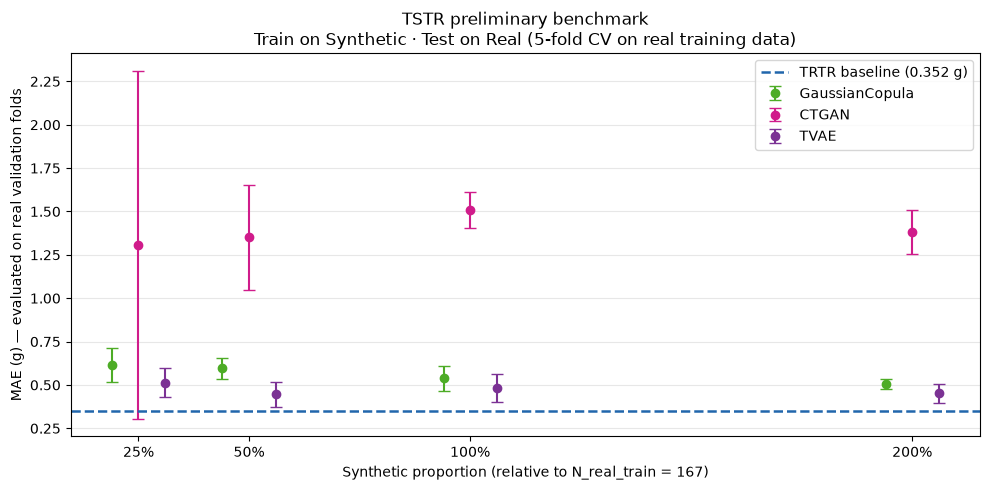

Saved: results/figures/fig_tstr_preliminary.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

model_colors = {"gaussian_copula": "#4dac26", "ctgan": "#d01c8b", "tvae": "#7b3294"}
model_labels = {"gaussian_copula": "GaussianCopula", "ctgan": "CTGAN", "tvae": "TVAE"}
# Horizontal offsets prevent point overlap between models at the same proportion.
offsets      = {"gaussian_copula": -0.06, "ctgan": 0.0, "tvae": 0.06}

for sname in ["gaussian_copula", "ctgan", "tvae"]:
    sub = df_tstr[df_tstr["model"] == sname]
    agg = sub.groupby("proportion")["MAE_mean"].agg(["mean", "std"]).reset_index()
    for _, row in agg.iterrows():
        x = row["proportion"] + offsets[sname]
        ax.errorbar(
            x, row["mean"], yerr=row["std"],
            fmt="o", color=model_colors[sname],
            capsize=4, markersize=6,
            # Only add label for the first proportion to avoid duplicate legend entries.
            label=model_labels[sname] if row["proportion"] == PROPORTIONS[0] else "",
        )

# TRTR baseline — train and test on real data (reference performance ceiling).
ax.axhline(
    trtr_mae_mean,
    color="#2166ac", linestyle="--", linewidth=1.8,
    label=f"TRTR baseline ({trtr_mae_mean:.3f} g)"
)

ax.set_xlabel("Synthetic proportion (relative to N_real_train = 167)")
ax.set_ylabel("MAE (g) — evaluated on real validation folds")
ax.set_title(
    "TSTR preliminary benchmark\n"
    "Train on Synthetic · Test on Real (5-fold CV on real training data)"
)
ax.legend()
ax.set_xticks(PROPORTIONS)
ax.set_xticklabels([f"{p:.0%}" for p in PROPORTIONS])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig_tstr_preliminary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/fig_tstr_preliminary.png")

---
## 12 · Summary report

In [24]:
print("=" * 60)
print("PART 2 — SYNTHESIS SUMMARY")
print("=" * 60)

print(f"\nReal training set    : {N_REAL_TRAIN} records")
print(f"Synthesisers fitted  : {list(fitted.keys())}")
print(f"Replicas per config  : {N_REPLICAS}")
print(f"Augmentation props   : {PROPORTIONS}")
print(f"Total synthetic files: {len(manifest)}")
print(f"Metadata persisted   : {METADATA_PATH}")

print("\n── Biological validity pass rates ──")
print(
    df_manifest.groupby("model")["pass_rate"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "mean_pass", "std": "std_pass"})
    .round(3)
)

print("\n── Allometric exponent fidelity (b₁ ref=1.621, b₂ ref=0.876, b₃ ref=0.393) ──")
print(
    df_coefs.groupby("source")[["b_length_cm", "b_width_cm", "b_thickness_cm"]]
    .mean()
    .round(4)
)

print("\n── TSTR vs TRTR (mean MAE, g) ──")
print(f"  TRTR baseline : {trtr_mae_mean:.4f} g (R² = {trtr_r2_mean:.4f})")
print(df_tstr.groupby("model")["MAE_mean"].mean().round(4))

print("\n── Files generated ──")
for d in [SYNTHETIC_DIR, METRICS_DIR, FIGURES_DIR, CONFIGS_DIR]:
    files = list(d.glob("*"))
    print(f"  {d}  ({len(files)} files)")

print("\n" + "=" * 60)
print("Sealed test set untouched. Proceed to Part 3.")
print("=" * 60)

PART 2 — SYNTHESIS SUMMARY

Real training set    : 167 records
Synthesisers fitted  : ['gaussian_copula', 'ctgan', 'tvae']
Replicas per config  : 5
Augmentation props   : [0.25, 0.5, 1.0, 2.0]
Total synthetic files: 60
Metadata persisted   : configs/metadata.json

── Biological validity pass rates ──
                 mean_pass  std_pass
model                               
ctgan                0.533     0.068
gaussian_copula      0.910     0.029
tvae                 0.994     0.008

── Allometric exponent fidelity (b₁ ref=1.621, b₂ ref=0.876, b₃ ref=0.393) ──
                 b_length_cm  b_width_cm  b_thickness_cm
source                                                  
ctgan                 0.6257      0.7853          0.0699
gaussian_copula       0.6521      1.9689          0.1733
real_train            1.6210      0.8759          0.3933
tvae                  1.2373      0.7553          0.7375

── TSTR vs TRTR (mean MAE, g) ──
  TRTR baseline : 0.3522 g (R² = 0.9729)
model
ctgan      